# Bankruptcy Prediction - EDA & Feature Engineering

## Project Overview
This notebook performs comprehensive Exploratory Data Analysis (EDA) on the Taiwan Economic Journal bankruptcy dataset, followed by feature reduction and clustering for model development.

**Key Objectives:**
1. Understand data structure and quality
2. Analyze class imbalance 
3. Explore feature distributions and relationships
4. Identify outliers and anomalies
5. Reduce features for efficient modeling
6. Create clusters for specialized models

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Feature Selection
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

import joblib

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42

In [2]:
# Load the dataset
df = pd.read_csv('train_data.csv')
df.head()

,Index,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0,0,0.450397,0.504034,0.506986,0.594640,0.594640,0.998906,0.797293,0.809239,...,0.780554,0.004919,0.623634,0.594641,0.838869,0.279036,0.026788,0.565144,1,0.032464
1,1,0,0.530005,0.572885,0.574763,0.605695,0.605558,0.999058,0.797512,0.809399,...,0.819963,0.005968,0.624171,0.605690,0.841869,0.279040,0.026801,0.565205,1,0.032442
2,2,0,0.571150,0.620148,0.624177,0.612275,0.612282,0.999163,0.797654,0.809533,...,0.839128,0.006022,0.625306,0.612271,0.843294,0.278927,0.026816,0.565276,1,0.033034
3,3,0,0.483401,0.556694,0.536164,0.602445,0.602445,0.999035,0.797458,0.809380,...,0.806477,0.002177,0.621610,0.602444,0.841891,0.293391,0.027063,0.566190,1,0.015406
4,4,0,0.510359,0.537287,0.552546,0.600023,0.600023,0.999009,0.797406,0.809313,...,0.799277,0.001124,0.623993,0.600019,0.840313,0.279878,0.026880,0.565549,1,0.028858


---
## 1. Data Loading & Initial Inspection

In [3]:
# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5807 entries, 0 to 5806
Data columns (total 97 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Index                                                     5807 non-null   int64  
 1   Bankrupt?                                                 5807 non-null   int64  
 2    ROA(C) before interest and depreciation before interest  5807 non-null   float64
 3    ROA(A) before interest and % after tax                   5807 non-null   float64
 4    ROA(B) before interest and depreciation after tax        5807 non-null   float64
 5    Operating Gross Margin                                   5807 non-null   float64
 6    Realized Sales Gross Margin                              5807 non-null   float64
 7    Operating Profit Rate                                    5807 non-null   float64
 8    Pre-tax net Inter

In [4]:
print(df.describe())

             Index    Bankrupt?  \
count  5807.000000  5807.000000   
mean   2903.000000     0.034097   
std    1676.480838     0.181493   
min       0.000000     0.000000   
25%    1451.500000     0.000000   
50%    2903.000000     0.000000   
75%    4354.500000     0.000000   
max    5806.000000     1.000000   

        ROA(C) before interest and depreciation before interest  \
count                                        5807.000000          
mean                                            0.505416          
std                                             0.060808          
min                                             0.000000          
25%                                             0.476673          
50%                                             0.503096          
75%                                             0.535417          
max                                             1.000000          

        ROA(A) before interest and % after tax  \
count                         

In [5]:
print(df.shape)
print(df["Bankrupt?"].value_counts())

(5807, 97)
Bankrupt?
0    5609
1     198
Name: count, dtype: int64


---
## 2. Target Variable Analysis (Class Imbalance)

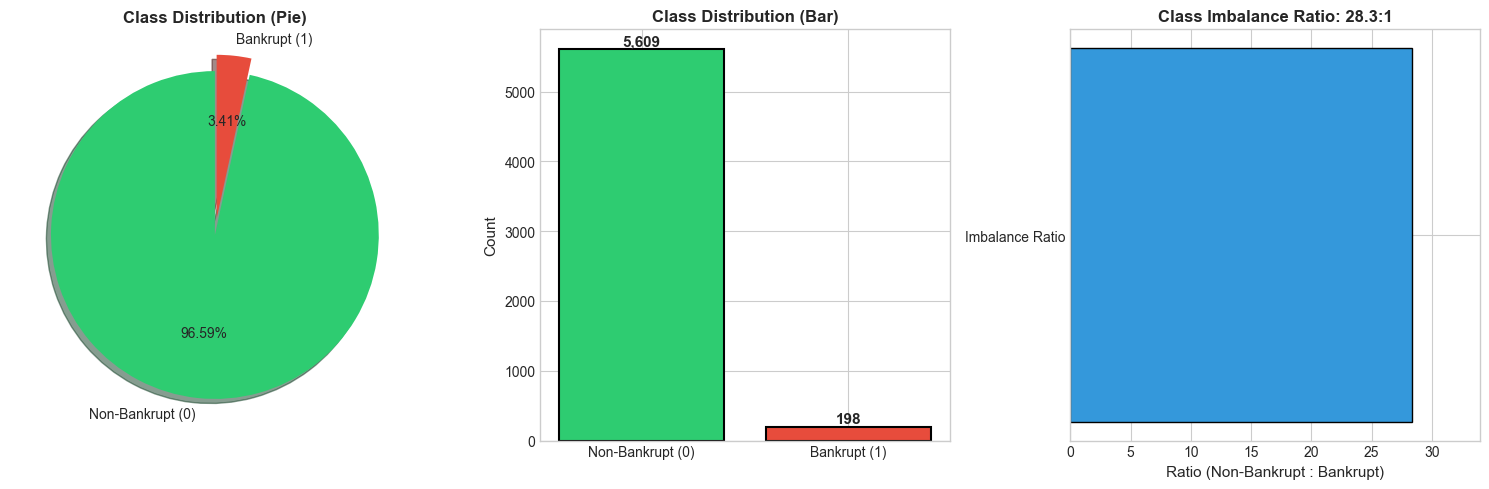


CLASS IMBALANCE SUMMARY
Total Samples: 5,807
Non-Bankrupt (0): 5,609 (96.59%)
Bankrupt (1): 198 (3.41%)
Imbalance Ratio: 28.3:1


In [6]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart
bankrupt_counts = df["Bankrupt?"].value_counts()
labels = ['Non-Bankrupt (0)', 'Bankrupt (1)']
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)

axes[0].pie(bankrupt_counts, explode=explode, labels=labels, colors=colors,
            autopct='%1.2f%%', shadow=True, startangle=90)
axes[0].set_title('Class Distribution (Pie)', fontsize=12, fontweight='bold')

# Bar chart
bars = axes[1].bar(labels, bankrupt_counts, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Class Distribution (Bar)', fontsize=12, fontweight='bold')
for bar, count in zip(bars, bankrupt_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'{count:,}', ha='center', fontsize=11, fontweight='bold')

# Imbalance ratio visualization
imbalance_ratio = bankrupt_counts[0] / bankrupt_counts[1]
axes[2].barh(['Imbalance Ratio'], [imbalance_ratio], color='#3498db', edgecolor='black')
axes[2].set_xlabel('Ratio (Non-Bankrupt : Bankrupt)', fontsize=11)
axes[2].set_title(f'Class Imbalance Ratio: {imbalance_ratio:.1f}:1', fontsize=12, fontweight='bold')
axes[2].set_xlim(0, imbalance_ratio * 1.2)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"CLASS IMBALANCE SUMMARY")
print(f"{'='*60}")
print(f"Total Samples: {len(df):,}")
print(f"Non-Bankrupt (0): {bankrupt_counts[0]:,} ({bankrupt_counts[0]/len(df)*100:.2f}%)")
print(f"Bankrupt (1): {bankrupt_counts[1]:,} ({bankrupt_counts[1]/len(df)*100:.2f}%)")
print(f"Imbalance Ratio: {imbalance_ratio:.1f}:1")
print(f"{'='*60}")

---
## 3. Missing Values & Data Quality Analysis

In [7]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

print(f"{'='*60}")
print(f"MISSING VALUES ANALYSIS")
print(f"{'='*60}")
print(f"Total Features: {df.shape[1]}")
print(f"Features with Missing Values: {(missing > 0).sum()}")
print(f"Total Missing Values: {missing.sum()}")

if missing.sum() > 0:
    missing_df = pd.DataFrame({
        'Missing Count': missing[missing > 0],
        'Missing %': missing_pct[missing_pct > 0]
    }).sort_values('Missing Count', ascending=False)
    print("\nFeatures with Missing Values:")
    print(missing_df)
else:
    print("\n✓ No missing values detected - Dataset is complete!")

# Check for infinite values
print(f"\n{'='*60}")
print("INFINITE VALUES CHECK")
print(f"{'='*60}")
X_check = df.drop(columns=['Index', 'Bankrupt?'])
inf_count = np.isinf(X_check.select_dtypes(include=[np.number])).sum().sum()
print(f"Infinite values found: {inf_count}")

# Check for duplicates
print(f"\n{'='*60}")
print("DUPLICATE ROWS CHECK")
print(f"{'='*60}")
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# Data types summary
print(f"\n{'='*60}")
print("DATA TYPES SUMMARY")
print(f"{'='*60}")
print(df.dtypes.value_counts())

MISSING VALUES ANALYSIS
Total Features: 97
Features with Missing Values: 0
Total Missing Values: 0

✓ No missing values detected - Dataset is complete!

INFINITE VALUES CHECK
Infinite values found: 0

DUPLICATE ROWS CHECK
Duplicate rows: 0

DATA TYPES SUMMARY
float64    93
int64       4
Name: count, dtype: int64


---
## 4. Feature Distribution Analysis

In [8]:
# Separate features by target class
X_features = df.drop(columns=['Index', 'Bankrupt?'])
feature_names = X_features.columns.tolist()

# Calculate statistics for each class
bankrupt = df[df['Bankrupt?'] == 1]
non_bankrupt = df[df['Bankrupt?'] == 0]

print(f"{'='*60}")
print("DESCRIPTIVE STATISTICS BY CLASS")
print(f"{'='*60}")
print(f"\nNon-Bankrupt companies: {len(non_bankrupt)}")
print(f"Bankrupt companies: {len(bankrupt)}")

# Summary statistics comparison
stats_comparison = pd.DataFrame({
    'Non-Bankrupt Mean': non_bankrupt[feature_names].mean(),
    'Bankrupt Mean': bankrupt[feature_names].mean(),
    'Difference': bankrupt[feature_names].mean() - non_bankrupt[feature_names].mean(),
    'Overall Std': X_features.std()
})
stats_comparison['Standardized Diff'] = stats_comparison['Difference'] / stats_comparison['Overall Std']
stats_comparison = stats_comparison.sort_values('Standardized Diff', key=abs, ascending=False)

print("\nTop 15 Features by Standardized Mean Difference:")
print(stats_comparison.head(15).round(4))

DESCRIPTIVE STATISTICS BY CLASS

Non-Bankrupt companies: 5609
Bankrupt companies: 198

Top 15 Features by Standardized Mean Difference:
                                                    Non-Bankrupt Mean  \
Net Income to Total Assets                                     0.8103   
ROA(A) before interest and % after tax                         0.5623   
ROA(B) before interest and depreciation after tax              0.5570   
ROA(C) before interest and depreciation before ...             0.5084   
Debt ratio %                                                   0.1105   
Net worth/Assets                                               0.8895   
Retained Earnings to Total Assets                              0.9361   
Persistent EPS in the Last Four Seasons                        0.2303   
Net profit before tax/Paid-in capital                          0.1841   
Per Share Net profit before tax (Yuan ¥)                       0.1858   
Working Capital to Total Assets                              

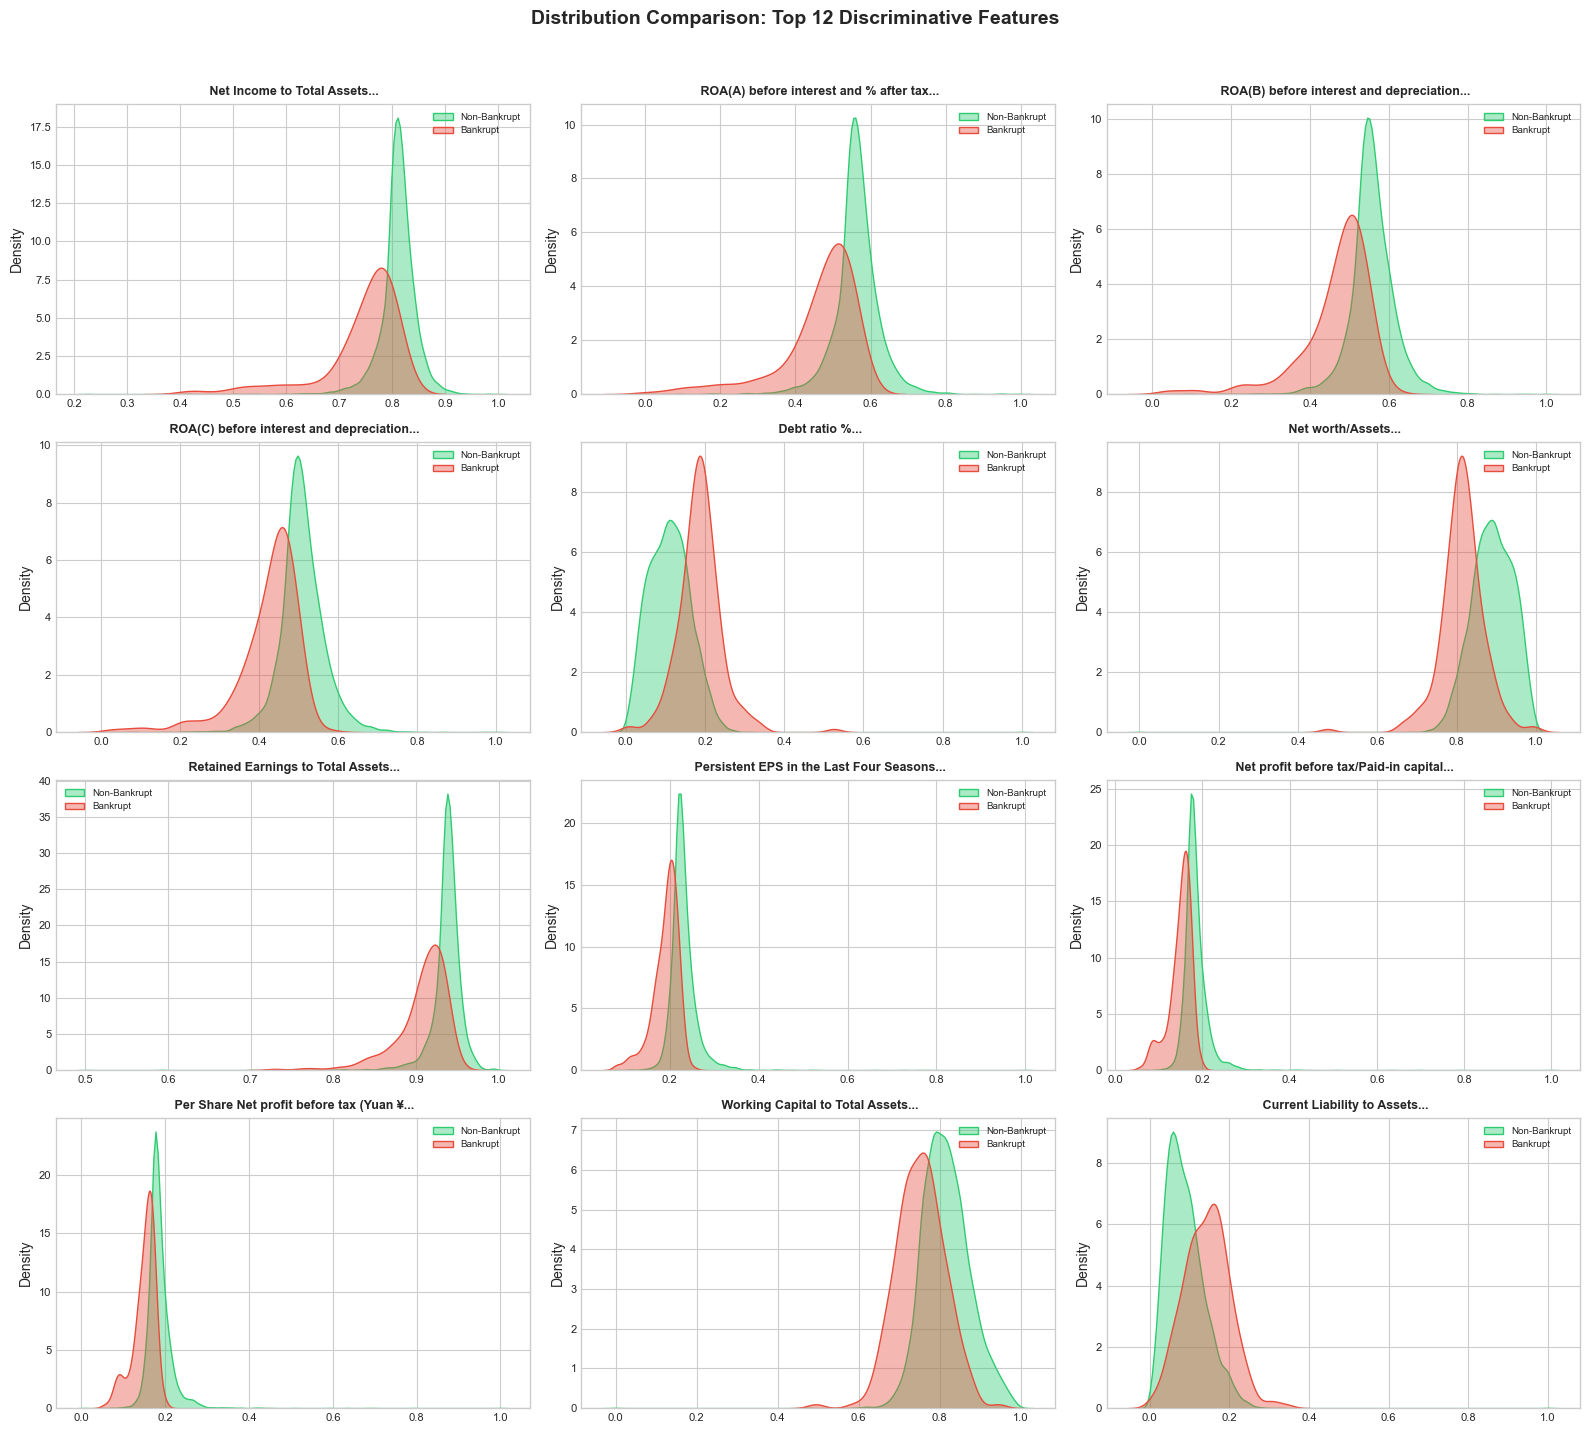

In [9]:
# Distribution plots for top discriminative features
top_features_viz = stats_comparison.head(12).index.tolist()

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, feature in enumerate(top_features_viz):
    ax = axes[idx]
    
    # KDE plot for both classes
    sns.kdeplot(data=non_bankrupt[feature], ax=ax, label='Non-Bankrupt', 
                color='#2ecc71', fill=True, alpha=0.4)
    sns.kdeplot(data=bankrupt[feature], ax=ax, label='Bankrupt', 
                color='#e74c3c', fill=True, alpha=0.4)
    
    ax.set_title(f'{feature[:40]}...', fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

plt.suptitle('Distribution Comparison: Top 12 Discriminative Features', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

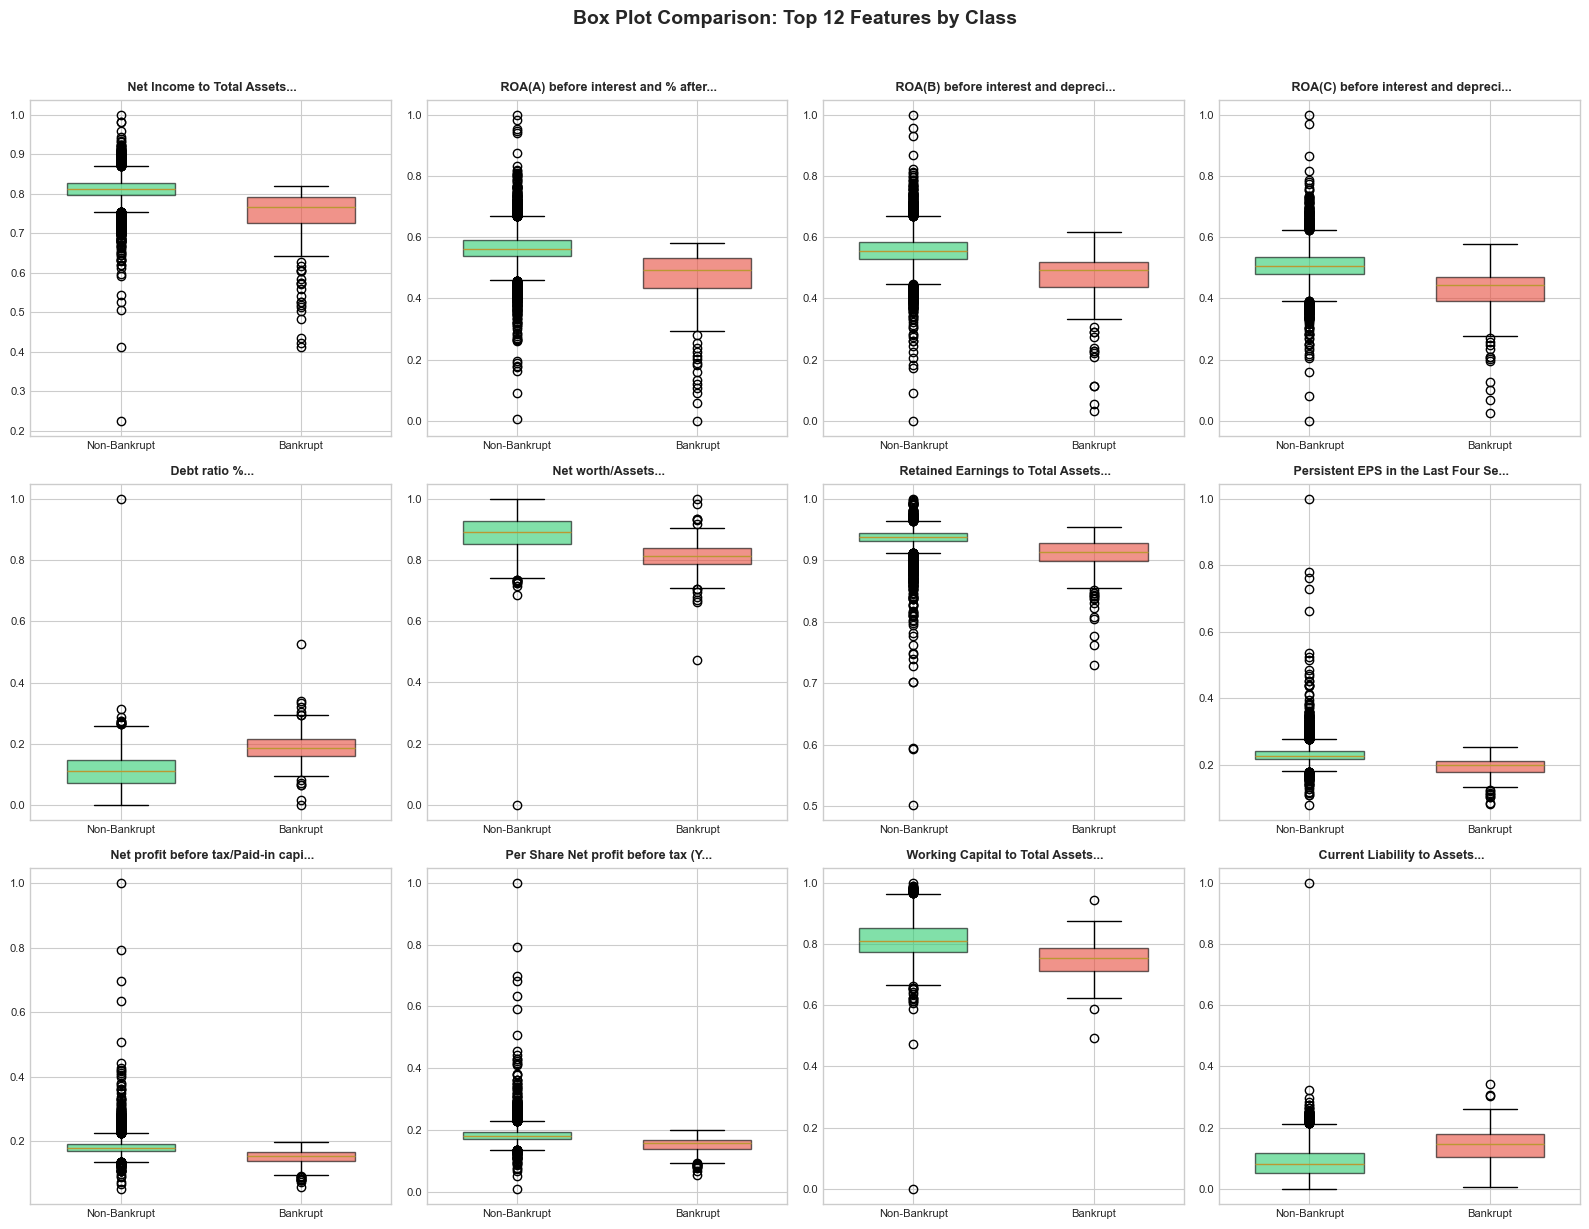

In [10]:
# Box plots to compare distributions between classes
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features_viz):
    ax = axes[idx]
    
    # Create boxplot data
    data_to_plot = [non_bankrupt[feature].values, bankrupt[feature].values]
    bp = ax.boxplot(data_to_plot, labels=['Non-Bankrupt', 'Bankrupt'], 
                    patch_artist=True, widths=0.6)
    
    colors = ['#2ecc71', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(f'{feature[:35]}...', fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=8)

plt.suptitle('Box Plot Comparison: Top 12 Features by Class', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Outlier Analysis

In [11]:
# Outlier detection using IQR method
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

outlier_counts = X_features.apply(count_outliers_iqr)
outlier_pct = (outlier_counts / len(df)) * 100

outlier_df = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Outlier %': outlier_pct
}).sort_values('Outlier %', ascending=False)

print(f"{'='*60}")
print("OUTLIER ANALYSIS (IQR Method)")
print(f"{'='*60}")
print(f"Features with >10% outliers: {(outlier_pct > 10).sum()}")
print(f"Features with >20% outliers: {(outlier_pct > 20).sum()}")
print(f"Features with >30% outliers: {(outlier_pct > 30).sum()}")

print("\nTop 20 Features by Outlier Percentage:")
print(outlier_df.head(20).round(2))

OUTLIER ANALYSIS (IQR Method)
Features with >10% outliers: 30
Features with >20% outliers: 5
Features with >30% outliers: 0

Top 20 Features by Outlier Percentage:
                                                    Outlier Count  Outlier %
Degree of Financial Leverage (DFL)                           1274      21.94
Fixed Assets Turnover Frequency                              1215      20.92
Interest Coverage Ratio (Interest expense to EBIT)           1208      20.80
Current Asset Turnover Rate                                  1188      20.46
Total Asset Growth Rate                                      1188      20.46
Interest Expense Ratio                                       1153      19.86
Cash Flow to Liability                                       1026      17.67
No-credit Interval                                            961      16.55
Non-industry income and expenditure/revenue                   941      16.20
Cash Flow to Sales                                            898 

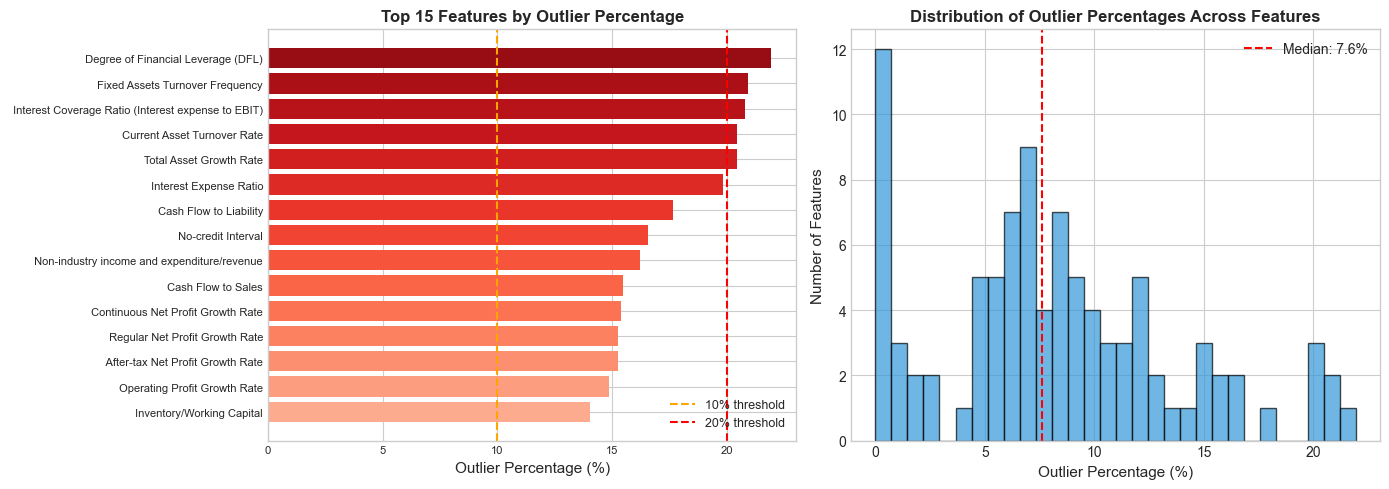

In [12]:
# Visualize outlier distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of top outlier features
top_outlier_features = outlier_df.head(15)
ax1 = axes[0]
bars = ax1.barh(top_outlier_features.index[::-1], top_outlier_features['Outlier %'].values[::-1], 
                color=plt.cm.Reds(np.linspace(0.3, 0.9, 15)))
ax1.set_xlabel('Outlier Percentage (%)', fontsize=11)
ax1.set_title('Top 15 Features by Outlier Percentage', fontsize=12, fontweight='bold')
ax1.axvline(x=10, color='orange', linestyle='--', label='10% threshold')
ax1.axvline(x=20, color='red', linestyle='--', label='20% threshold')
ax1.legend(fontsize=9)
ax1.tick_params(labelsize=8)

# Histogram of outlier percentages
ax2 = axes[1]
ax2.hist(outlier_pct, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Outlier Percentage (%)', fontsize=11)
ax2.set_ylabel('Number of Features', fontsize=11)
ax2.set_title('Distribution of Outlier Percentages Across Features', fontsize=12, fontweight='bold')
ax2.axvline(x=outlier_pct.median(), color='red', linestyle='--', 
            label=f'Median: {outlier_pct.median():.1f}%')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 6. Correlation Analysis

In [13]:
# Correlation with target variable
target_correlation = X_features.apply(lambda x: x.corr(df['Bankrupt?']))
target_correlation = target_correlation.sort_values(key=abs, ascending=False)

print(f"{'='*60}")
print("CORRELATION WITH TARGET (Bankrupt?)")
print(f"{'='*60}")
print("\nTop 20 Features Most Correlated with Bankruptcy:")
print(target_correlation.head(20).round(4))

print("\nBottom 10 Features Least Correlated with Bankruptcy:")
print(target_correlation.tail(10).round(4))

CORRELATION WITH TARGET (Bankrupt?)

Top 20 Features Most Correlated with Bankruptcy:
Net Income to Total Assets                                -0.3195
ROA(A) before interest and % after tax                    -0.2794
ROA(B) before interest and depreciation after tax         -0.2694
ROA(C) before interest and depreciation before interest   -0.2583
Net worth/Assets                                          -0.2559
Debt ratio %                                               0.2559
Retained Earnings to Total Assets                         -0.2452
Persistent EPS in the Last Four Seasons                   -0.2138
Net profit before tax/Paid-in capital                     -0.2028
Per Share Net profit before tax (Yuan ¥)                  -0.1965
Working Capital to Total Assets                           -0.1957
Current Liability to Assets                                0.1952
Borrowing dependency                                       0.1941
Net Income to Stockholder's Equity                      

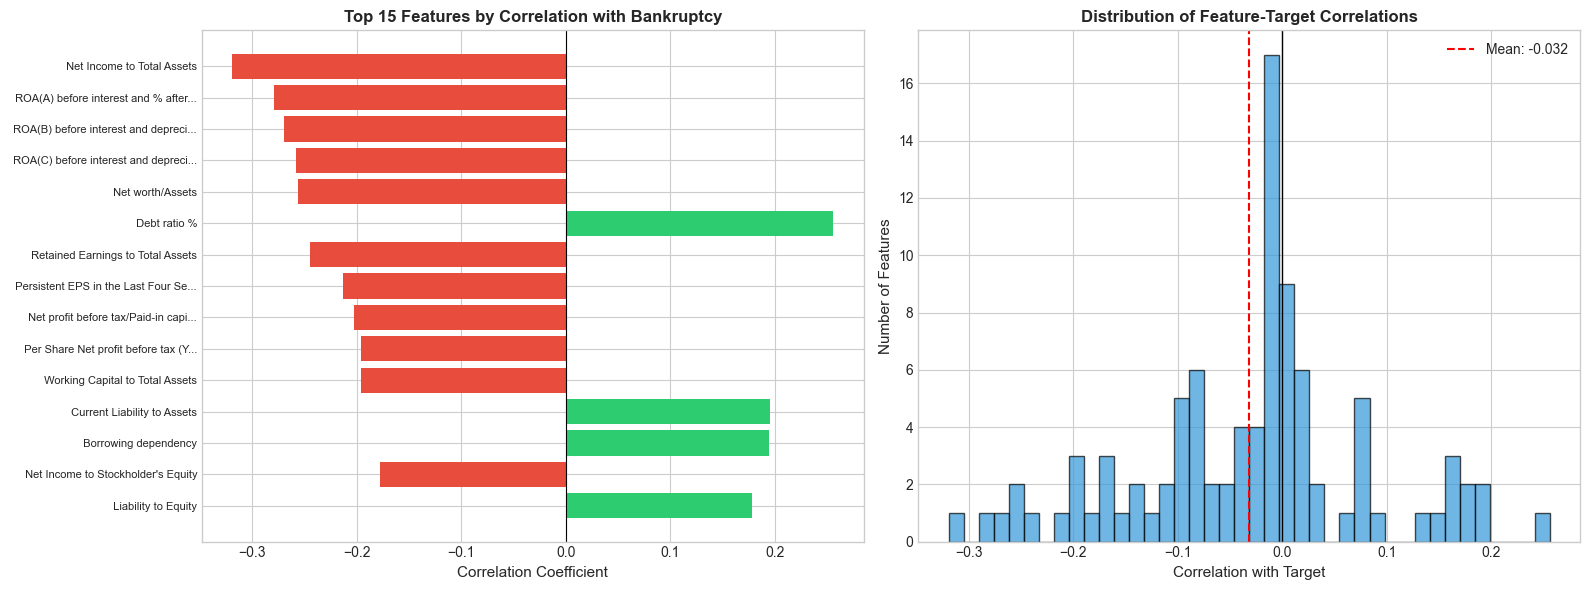

In [14]:
# Visualize target correlation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top positive and negative correlations
top_corr = target_correlation.head(15)
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_corr.values]

ax1 = axes[0]
ax1.barh(range(len(top_corr)), top_corr.values, color=colors)
ax1.set_yticks(range(len(top_corr)))
ax1.set_yticklabels([f'{name[:35]}...' if len(name) > 35 else name for name in top_corr.index], fontsize=8)
ax1.set_xlabel('Correlation Coefficient', fontsize=11)
ax1.set_title('Top 15 Features by Correlation with Bankruptcy', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.invert_yaxis()

# Distribution of all correlations
ax2 = axes[1]
ax2.hist(target_correlation, bins=40, color='#3498db', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Correlation with Target', fontsize=11)
ax2.set_ylabel('Number of Features', fontsize=11)
ax2.set_title('Distribution of Feature-Target Correlations', fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.axvline(x=target_correlation.mean(), color='red', linestyle='--', 
            label=f'Mean: {target_correlation.mean():.3f}')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
# Feature-to-feature correlation analysis (using top correlated features)
top_corr_features = target_correlation.head(20).index.tolist()

# Compute correlation matrix for top features
corr_matrix = X_features[top_corr_features].corr()

# Find highly correlated feature pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i][:30],
                'Feature 2': corr_matrix.columns[j][:30],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"{'='*60}")
print("HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.8)")
print(f"{'='*60}")
print(f"Found {len(high_corr_pairs)} highly correlated pairs among top 20 features\n")

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.head(15).to_string(index=False))

HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.8)
Found 18 highly correlated pairs among top 20 features

                     Feature 1                      Feature 2  Correlation
              Net worth/Assets                   Debt ratio %    -1.000000
       Net Value Per Share (A)        Net Value Per Share (C)     0.999820
       Net Value Per Share (A)        Net Value Per Share (B)     0.999256
       Net Value Per Share (B)        Net Value Per Share (C)     0.999076
 ROA(B) before interest and de  ROA(C) before interest and de     0.986581
    Net Income to Total Assets  ROA(A) before interest and %      0.972268
 Net profit before tax/Paid-in  Per Share Net profit before t     0.960669
 Persistent EPS in the Last Fo  Net profit before tax/Paid-in     0.957085
 ROA(A) before interest and %   ROA(B) before interest and de     0.954590
 Persistent EPS in the Last Fo  Per Share Net profit before t     0.954129
          Borrowing dependency            Liability to Equity     0.953580


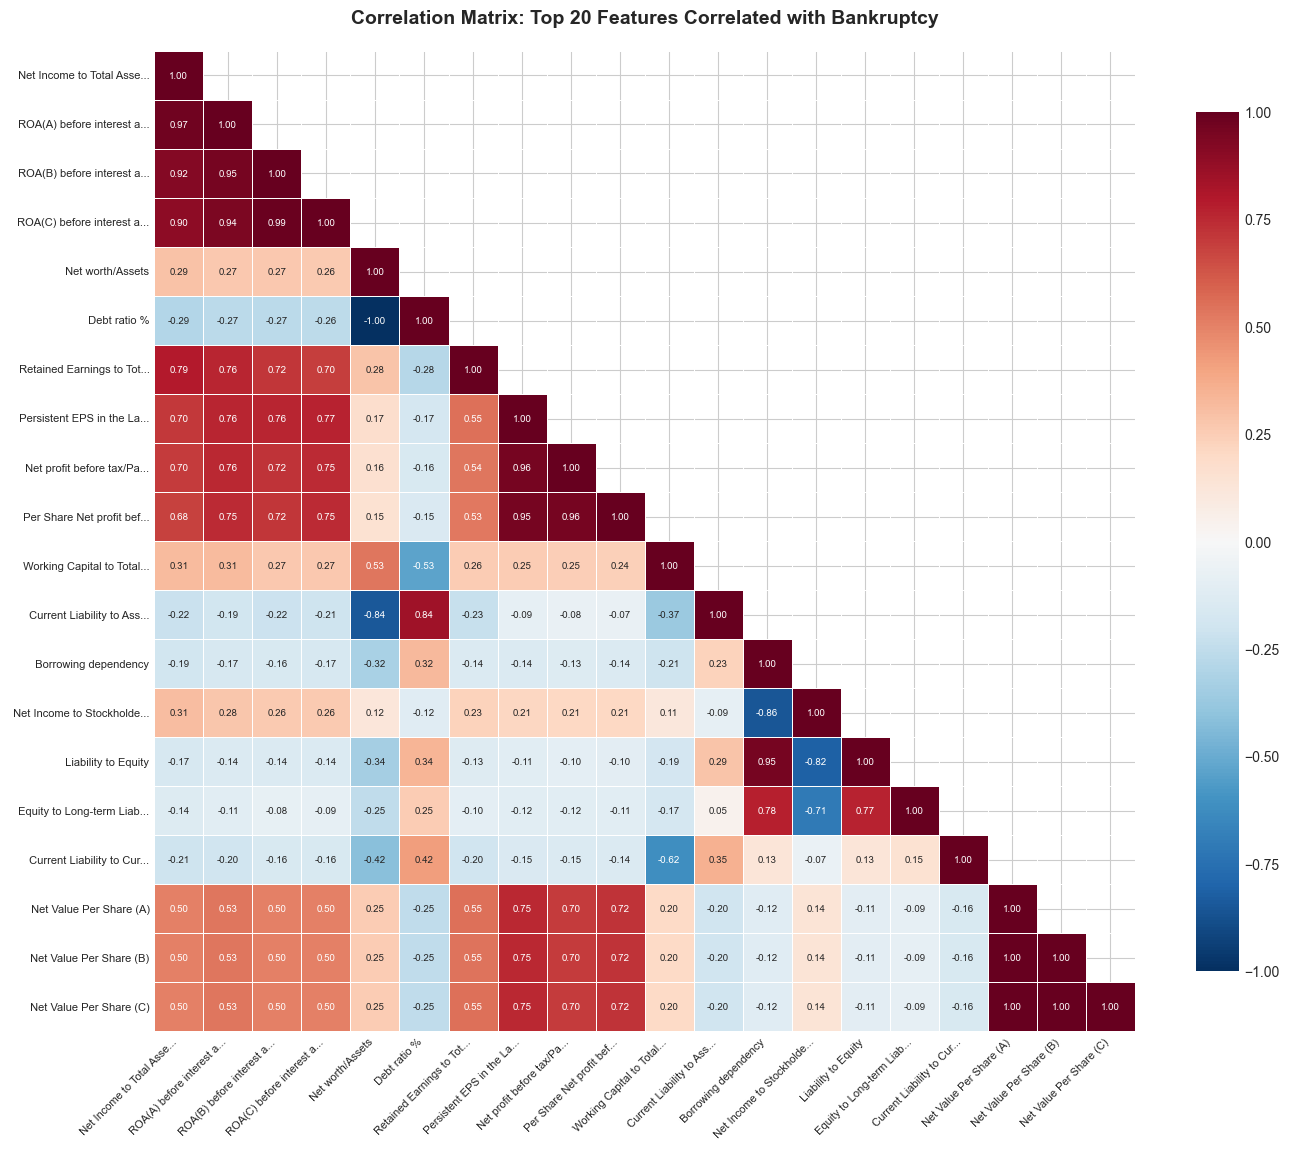

In [16]:
# Correlation heatmap for top features
plt.figure(figsize=(14, 12))

# Shorten feature names for display
short_names = [name[:25] + '...' if len(name) > 25 else name for name in top_corr_features]

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            xticklabels=short_names, yticklabels=short_names,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix: Top 20 Features Correlated with Bankruptcy', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

---
## 7. Skewness & Kurtosis Analysis

In [17]:
# Skewness and Kurtosis analysis
from scipy import stats

skewness = X_features.apply(lambda x: stats.skew(x.dropna()))
kurtosis = X_features.apply(lambda x: stats.kurtosis(x.dropna()))

skew_kurt_df = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurtosis,
    'Abs_Skewness': abs(skewness)
}).sort_values('Abs_Skewness', ascending=False)

print(f"{'='*60}")
print("SKEWNESS & KURTOSIS ANALYSIS")
print(f"{'='*60}")
print(f"\nHighly Skewed Features (|skew| > 2): {(abs(skewness) > 2).sum()}")
print(f"Moderately Skewed Features (1 < |skew| <= 2): {((abs(skewness) > 1) & (abs(skewness) <= 2)).sum()}")
print(f"Approximately Symmetric (|skew| <= 1): {(abs(skewness) <= 1).sum()}")

print("\nTop 15 Most Skewed Features:")
print(skew_kurt_df.drop('Abs_Skewness', axis=1).head(15).round(3))

SKEWNESS & KURTOSIS ANALYSIS

Highly Skewed Features (|skew| > 2): 74
Moderately Skewed Features (1 < |skew| <= 2): 8
Approximately Symmetric (|skew| <= 1): 12

Top 15 Most Skewed Features:
                                         Skewness  Kurtosis
Revenue per person                         76.184  5802.000
Current Ratio                              76.184  5802.000
Fixed Assets to Assets                     76.184  5802.000
Total income/Total expense                 75.975  5780.626
Net Value Growth Rate                      74.075  5568.772
Contingent liabilities/Net worth           73.860  5560.225
Realized Sales Gross Profit Growth Rate    72.671  5436.335
Operating Profit Growth Rate              -66.270  4849.418
Operating Profit Rate                     -64.944  4446.490
Continuous Net Profit Growth Rate          61.961  4597.378
Total Asset Return Growth Rate Ratio       57.798  4331.808
Quick Assets/Current Liability             54.346  2968.744
After-tax net Interest Rate   

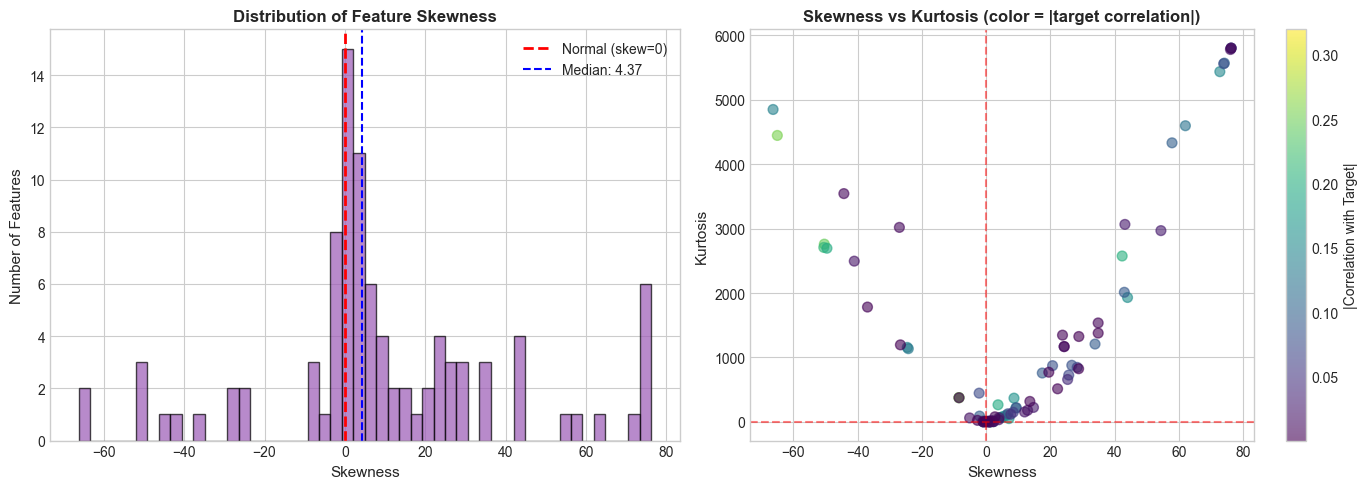

In [18]:
# Visualize skewness distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Skewness histogram
ax1 = axes[0]
ax1.hist(skewness, bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Skewness', fontsize=11)
ax1.set_ylabel('Number of Features', fontsize=11)
ax1.set_title('Distribution of Feature Skewness', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Normal (skew=0)')
ax1.axvline(x=skewness.median(), color='blue', linestyle='--', 
            label=f'Median: {skewness.median():.2f}')
ax1.legend(fontsize=10)

# Skewness vs Kurtosis scatter
ax2 = axes[1]
scatter = ax2.scatter(skewness, kurtosis, c=abs(target_correlation), 
                      cmap='viridis', alpha=0.6, s=50)
ax2.set_xlabel('Skewness', fontsize=11)
ax2.set_ylabel('Kurtosis', fontsize=11)
ax2.set_title('Skewness vs Kurtosis (color = |target correlation|)', 
              fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.5)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.colorbar(scatter, ax=ax2, label='|Correlation with Target|')

plt.tight_layout()
plt.show()

---
## 8. Feature Category Analysis

In [19]:
# Categorize features by financial metric type
def categorize_feature(name):
    name_lower = name.lower()
    if any(x in name_lower for x in ['roa', 'roe', 'return', 'profit rate', 'net income']):
        return 'Profitability'
    elif any(x in name_lower for x in ['debt', 'liability', 'leverage', 'borrowing']):
        return 'Leverage/Debt'
    elif any(x in name_lower for x in ['current ratio', 'quick', 'working capital', 'liquidity']):
        return 'Liquidity'
    elif any(x in name_lower for x in ['turnover', 'collection', 'inventory rate']):
        return 'Efficiency/Turnover'
    elif any(x in name_lower for x in ['cash flow', 'cash/', 'cfo']):
        return 'Cash Flow'
    elif any(x in name_lower for x in ['growth', 'rate ratio']):
        return 'Growth'
    elif any(x in name_lower for x in ['per share', 'eps']):
        return 'Per Share Metrics'
    elif any(x in name_lower for x in ['asset', 'net worth', 'equity']):
        return 'Asset/Equity'
    else:
        return 'Other'

feature_categories = {feat: categorize_feature(feat) for feat in feature_names}
category_counts = pd.Series(feature_categories).value_counts()

print(f"{'='*60}")
print("FEATURE CATEGORIES")
print(f"{'='*60}")
print(category_counts)
print(f"\nTotal Features: {len(feature_names)}")

FEATURE CATEGORIES
Other                  22
Leverage/Debt          20
Efficiency/Turnover     9
Profitability           8
Asset/Equity            8
Per Share Metrics       7
Cash Flow               7
Liquidity               7
Growth                  7
Name: count, dtype: int64

Total Features: 95


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


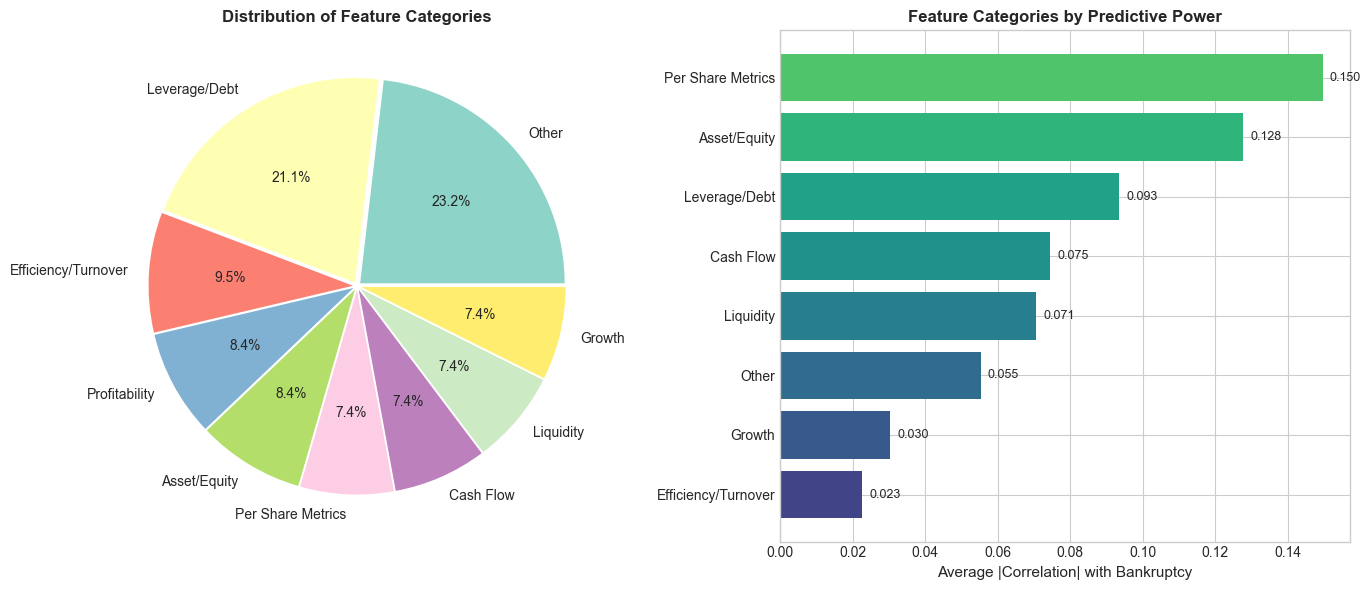

In [20]:
# Visualize feature categories and their correlation with target
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart of categories
ax1 = axes[0]
colors = plt.cm.Set3(np.linspace(0, 1, len(category_counts)))
wedges, texts, autotexts = ax1.pie(category_counts.values, labels=category_counts.index,
                                    autopct='%1.1f%%', colors=colors, 
                                    explode=[0.02]*len(category_counts))
ax1.set_title('Distribution of Feature Categories', fontsize=12, fontweight='bold')

# Average correlation by category
category_corr = {}
for feat, cat in feature_categories.items():
    if cat not in category_corr:
        category_corr[cat] = []
    category_corr[cat].append(abs(target_correlation[feat]))

avg_category_corr = {cat: np.mean(corrs) for cat, corrs in category_corr.items()}
avg_corr_series = pd.Series(avg_category_corr).sort_values(ascending=True)

ax2 = axes[1]
bars = ax2.barh(avg_corr_series.index, avg_corr_series.values, 
                color=plt.cm.viridis(np.linspace(0.2, 0.8, len(avg_corr_series))))
ax2.set_xlabel('Average |Correlation| with Bankruptcy', fontsize=11)
ax2.set_title('Feature Categories by Predictive Power', fontsize=12, fontweight='bold')

for bar, val in zip(bars, avg_corr_series.values):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 9. PCA Visualization

In [21]:
# PCA for dimensionality reduction visualization
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale features for PCA
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_features)

# Fit PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print(f"{'='*60}")
print("PCA ANALYSIS")
print(f"{'='*60}")
print("\nExplained Variance by Component:")
for i, (var, cum) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%) | Cumulative: {cum:.4f} ({cum*100:.2f}%)")

PCA ANALYSIS

Explained Variance by Component:
  PC1: 0.1345 (13.45%) | Cumulative: 0.1345 (13.45%)
  PC2: 0.0742 (7.42%) | Cumulative: 0.2086 (20.86%)
  PC3: 0.0527 (5.27%) | Cumulative: 0.2613 (26.13%)
  PC4: 0.0476 (4.76%) | Cumulative: 0.3089 (30.89%)
  PC5: 0.0427 (4.27%) | Cumulative: 0.3517 (35.17%)
  PC6: 0.0325 (3.25%) | Cumulative: 0.3842 (38.42%)
  PC7: 0.0311 (3.11%) | Cumulative: 0.4153 (41.53%)
  PC8: 0.0300 (3.00%) | Cumulative: 0.4453 (44.53%)
  PC9: 0.0281 (2.81%) | Cumulative: 0.4734 (47.34%)
  PC10: 0.0219 (2.19%) | Cumulative: 0.4953 (49.53%)


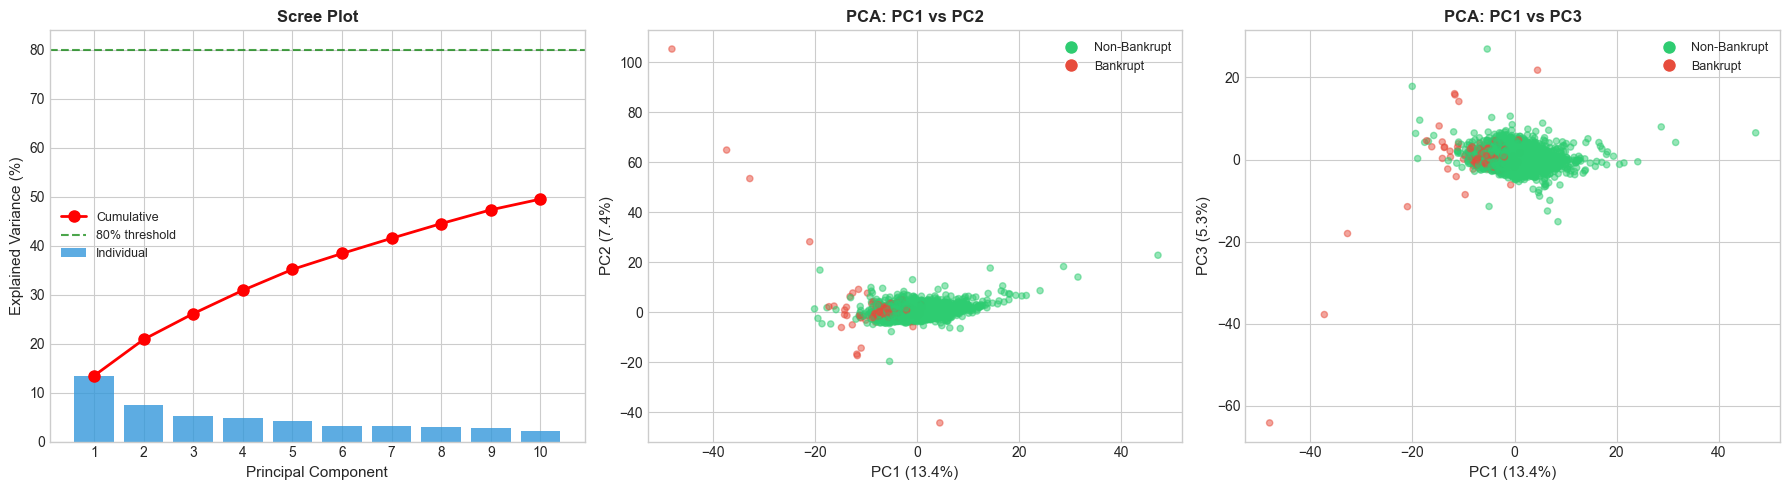

In [22]:
# PCA Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree plot
ax1 = axes[0]
x_pos = range(1, len(explained_var) + 1)
ax1.bar(x_pos, explained_var * 100, color='#3498db', alpha=0.8, label='Individual')
ax1.plot(x_pos, cumulative_var * 100, 'ro-', linewidth=2, markersize=8, label='Cumulative')
ax1.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% threshold')
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Explained Variance (%)', fontsize=11)
ax1.set_title('Scree Plot', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xticks(x_pos)

# 2D PCA plot (PC1 vs PC2)
ax2 = axes[1]
colors = ['#2ecc71' if y == 0 else '#e74c3c' for y in df['Bankrupt?']]
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.5, s=20)
ax2.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=11)
ax2.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=11)
ax2.set_title('PCA: PC1 vs PC2', fontsize=12, fontweight='bold')

# Create legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', 
                          markersize=10, label='Non-Bankrupt'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', 
                          markersize=10, label='Bankrupt')]
ax2.legend(handles=legend_elements, fontsize=9)

# 2D PCA plot (PC1 vs PC3)
ax3 = axes[2]
ax3.scatter(X_pca[:, 0], X_pca[:, 2], c=colors, alpha=0.5, s=20)
ax3.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=11)
ax3.set_ylabel(f'PC3 ({explained_var[2]*100:.1f}%)', fontsize=11)
ax3.set_title('PCA: PC1 vs PC3', fontsize=12, fontweight='bold')
ax3.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.show()

---
## 10. t-SNE Visualization

In [23]:
# t-SNE visualization (using PCA-reduced data for speed)
from sklearn.manifold import TSNE

print("Running t-SNE... (this may take a minute)")

# Use PCA first to reduce computation time
pca_50 = PCA(n_components=50)
X_pca_50 = pca_50.fit_transform(X_scaled)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca_50)

print("t-SNE complete!")

Running t-SNE... (this may take a minute)
t-SNE complete!
t-SNE complete!


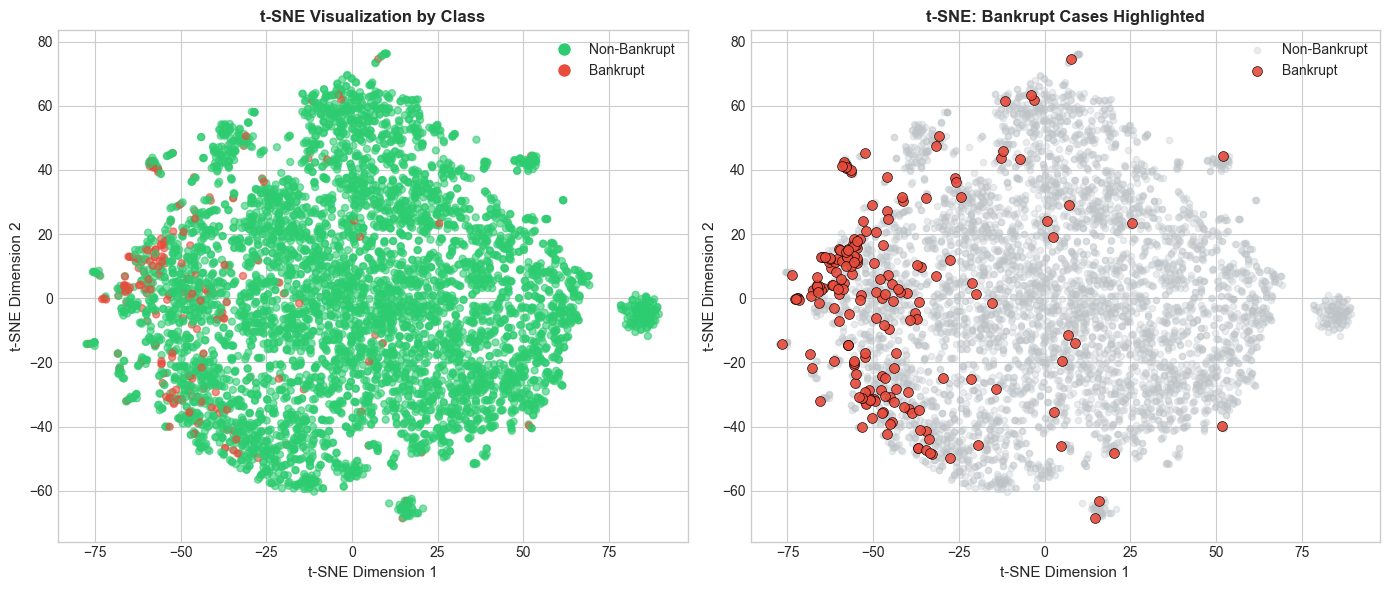


Note: Bankrupt cases (198) are highlighted to show their distribution pattern


In [24]:
# Plot t-SNE results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# t-SNE colored by class
ax1 = axes[0]
colors = ['#2ecc71' if y == 0 else '#e74c3c' for y in df['Bankrupt?']]
ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.6, s=25)
ax1.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax1.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax1.set_title('t-SNE Visualization by Class', fontsize=12, fontweight='bold')
ax1.legend(handles=legend_elements, fontsize=10)

# Highlight bankrupt cases only
ax2 = axes[1]
non_bankrupt_idx = df['Bankrupt?'] == 0
bankrupt_idx = df['Bankrupt?'] == 1

ax2.scatter(X_tsne[non_bankrupt_idx, 0], X_tsne[non_bankrupt_idx, 1], 
            c='#bdc3c7', alpha=0.3, s=20, label='Non-Bankrupt')
ax2.scatter(X_tsne[bankrupt_idx, 0], X_tsne[bankrupt_idx, 1], 
            c='#e74c3c', alpha=0.9, s=50, edgecolors='black', linewidth=0.5, label='Bankrupt')
ax2.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax2.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax2.set_title('t-SNE: Bankrupt Cases Highlighted', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nNote: Bankrupt cases ({bankrupt_idx.sum()}) are highlighted to show their distribution pattern")

---
## 11. Feature Variance Analysis

In [25]:
# Variance analysis
feature_variance = X_features.var().sort_values(ascending=False)

print(f"{'='*60}")
print("FEATURE VARIANCE ANALYSIS")
print(f"{'='*60}")
print(f"\nFeatures with very low variance (<1e-5): {(feature_variance < 1e-5).sum()}")
print(f"Features with low variance (<0.01): {(feature_variance < 0.01).sum()}")
print(f"Features with moderate variance (0.01-1): {((feature_variance >= 0.01) & (feature_variance < 1)).sum()}")
print(f"Features with high variance (>=1): {(feature_variance >= 1).sum()}")

print("\nTop 10 Highest Variance Features:")
print(feature_variance.head(10).round(4))

print("\nBottom 10 Lowest Variance Features:")
print(feature_variance.tail(10))

FEATURE VARIANCE ANALYSIS

Features with very low variance (<1e-5): 1
Features with low variance (<0.01): 64
Features with moderate variance (0.01-1): 7
Features with high variance (>=1): 24

Top 10 Highest Variance Features:
Quick Asset Turnover Rate                1.139883e+19
Operating Expense Rate                   1.048715e+19
Inventory Turnover Rate (times)          1.046861e+19
Cash Turnover Rate                       8.781596e+18
Total Asset Growth Rate                  8.460719e+18
Current Asset Turnover Rate              7.895578e+18
Research and development expense rate    6.833641e+18
Fixed Assets Turnover Frequency          6.132239e+18
Inventory/Current Liability              3.445297e+17
Long-term Liability to Current Assets    2.954872e+17
dtype: float64

Bottom 10 Lowest Variance Features:
Inventory/Working Capital                      0.000126
Degree of Financial Leverage (DFL)             0.000124
Inventory and accounts receivable/Net value    0.000120
Continuous Net

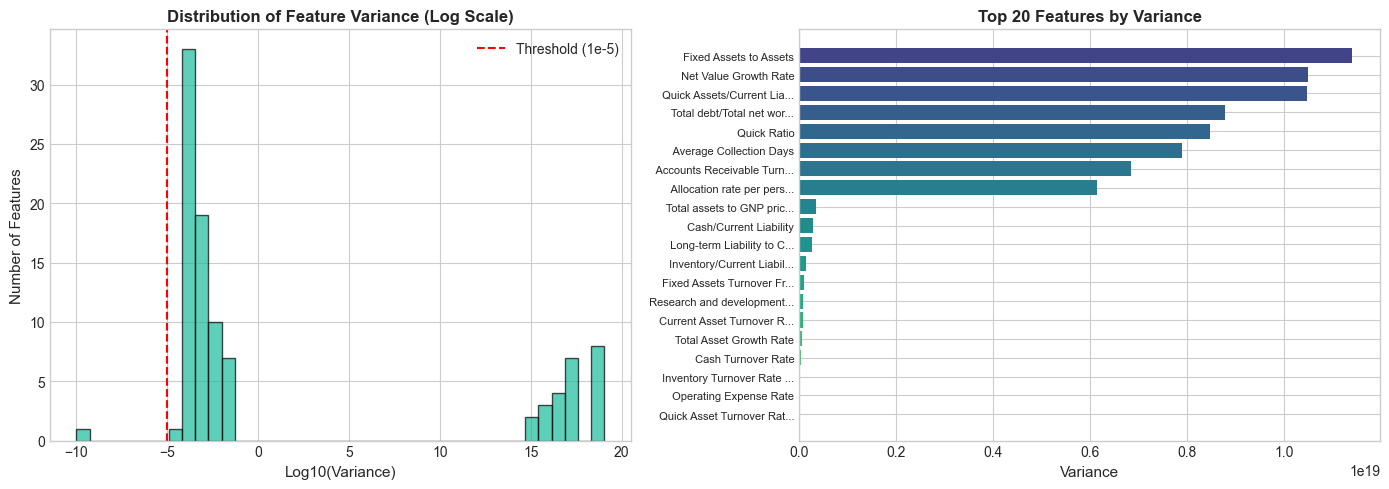

In [26]:
# Variance visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log variance distribution
ax1 = axes[0]
log_variance = np.log10(feature_variance + 1e-10)
ax1.hist(log_variance, bins=40, color='#1abc9c', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Log10(Variance)', fontsize=11)
ax1.set_ylabel('Number of Features', fontsize=11)
ax1.set_title('Distribution of Feature Variance (Log Scale)', fontsize=12, fontweight='bold')
ax1.axvline(x=np.log10(1e-5), color='red', linestyle='--', label='Threshold (1e-5)')
ax1.legend(fontsize=10)

# Top 20 variance features
ax2 = axes[1]
top_var = feature_variance.head(20)
short_names = [name[:25] + '...' if len(name) > 25 else name for name in top_var.index]
ax2.barh(range(len(top_var)), top_var.values, color=plt.cm.viridis(np.linspace(0.2, 0.8, 20)))
ax2.set_yticks(range(len(top_var)))
ax2.set_yticklabels(short_names[::-1], fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel('Variance', fontsize=11)
ax2.set_title('Top 20 Features by Variance', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 12. EDA Summary & Key Insights

In [27]:
# EDA Summary Dashboard
print("="*70)
print("                    EDA SUMMARY DASHBOARD                    ")
print("="*70)

print(f"""
📊 DATASET OVERVIEW
   • Total Samples: {len(df):,}
   • Total Features: {len(feature_names)}
   • Target: Binary (Bankrupt: 0/1)

⚖️ CLASS IMBALANCE
   • Non-Bankrupt: {(df['Bankrupt?']==0).sum():,} ({(df['Bankrupt?']==0).sum()/len(df)*100:.2f}%)
   • Bankrupt: {(df['Bankrupt?']==1).sum():,} ({(df['Bankrupt?']==1).sum()/len(df)*100:.2f}%)
   • Imbalance Ratio: {(df['Bankrupt?']==0).sum()/(df['Bankrupt?']==1).sum():.1f}:1

📈 DATA QUALITY
   • Missing Values: {df.isnull().sum().sum()}
   • Duplicate Rows: {df.duplicated().sum()}
   • Features with >20% Outliers: {(outlier_pct > 20).sum()}

🔗 FEATURE INSIGHTS
   • Highly Skewed Features (|skew|>2): {(abs(skewness) > 2).sum()}
   • Low Variance Features (<1e-5): {(feature_variance < 1e-5).sum()}
   • Strong Target Correlation (|r|>0.1): {(abs(target_correlation) > 0.1).sum()}

🎯 TOP PREDICTIVE CATEGORIES
   1. {list(avg_corr_series.index)[-1]} (avg |r| = {avg_corr_series.iloc[-1]:.3f})
   2. {list(avg_corr_series.index)[-2]} (avg |r| = {avg_corr_series.iloc[-2]:.3f})
   3. {list(avg_corr_series.index)[-3]} (avg |r| = {avg_corr_series.iloc[-3]:.3f})

📉 PCA INSIGHTS
   • PC1 explains {explained_var[0]*100:.1f}% of variance
   • Top 5 PCs explain {cumulative_var[4]*100:.1f}% of variance
   • Top 10 PCs explain {cumulative_var[9]*100:.1f}% of variance
""")
print("="*70)
print("                  READY FOR FEATURE REDUCTION                  ")
print("="*70)

                    EDA SUMMARY DASHBOARD                    

📊 DATASET OVERVIEW
   • Total Samples: 5,807
   • Total Features: 95
   • Target: Binary (Bankrupt: 0/1)

⚖️ CLASS IMBALANCE
   • Non-Bankrupt: 5,609 (96.59%)
   • Bankrupt: 198 (3.41%)
   • Imbalance Ratio: 28.3:1

📈 DATA QUALITY
   • Missing Values: 0
   • Duplicate Rows: 0
   • Features with >20% Outliers: 5

🔗 FEATURE INSIGHTS
   • Highly Skewed Features (|skew|>2): 74
   • Low Variance Features (<1e-5): 1
   • Strong Target Correlation (|r|>0.1): 30

🎯 TOP PREDICTIVE CATEGORIES
   1. Profitability (avg |r| = nan)
   2. Per Share Metrics (avg |r| = 0.150)
   3. Asset/Equity (avg |r| = 0.128)

📉 PCA INSIGHTS
   • PC1 explains 13.4% of variance
   • Top 5 PCs explain 35.2% of variance
   • Top 10 PCs explain 49.5% of variance

                  READY FOR FEATURE REDUCTION                  


---
---
# Part 2: Feature Reduction & Clustering

Now that we have a comprehensive understanding of the data, we proceed with:
1. Variance-based filtering
2. Random Forest importance ranking
3. Selection of top features
4. K-Means clustering for specialized models

In [28]:
# Target and ID
y = df["Bankrupt?"]
index_col = df["Index"]

# Drop ID and target for feature processing
X = df.drop(columns=["Index", "Bankrupt?"])
print(X.shape, y.value_counts())

(5807, 95) Bankrupt?
0    5609
1     198
Name: count, dtype: int64


In [29]:
var_thresh = VarianceThreshold(threshold=1e-5)
X_var = var_thresh.fit_transform(X)

# Keep track of which columns survived
selected_cols_step1 = X.columns[var_thresh.get_support()]
print("After variance filter:", X_var.shape)

After variance filter: (5807, 94)


In [30]:
X_var_df = pd.DataFrame(X_var, columns=selected_cols_step1)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf.fit(X_var_df, y)

# Get importances and pick top k
importances = pd.Series(rf.feature_importances_, index=X_var_df.columns)
importances = importances.sort_values(ascending=False)

TOP_K = 40  # you can adjust between 30–40
top_features = importances.head(TOP_K).index.tolist()
print("Top features:", len(top_features))

Top features: 40


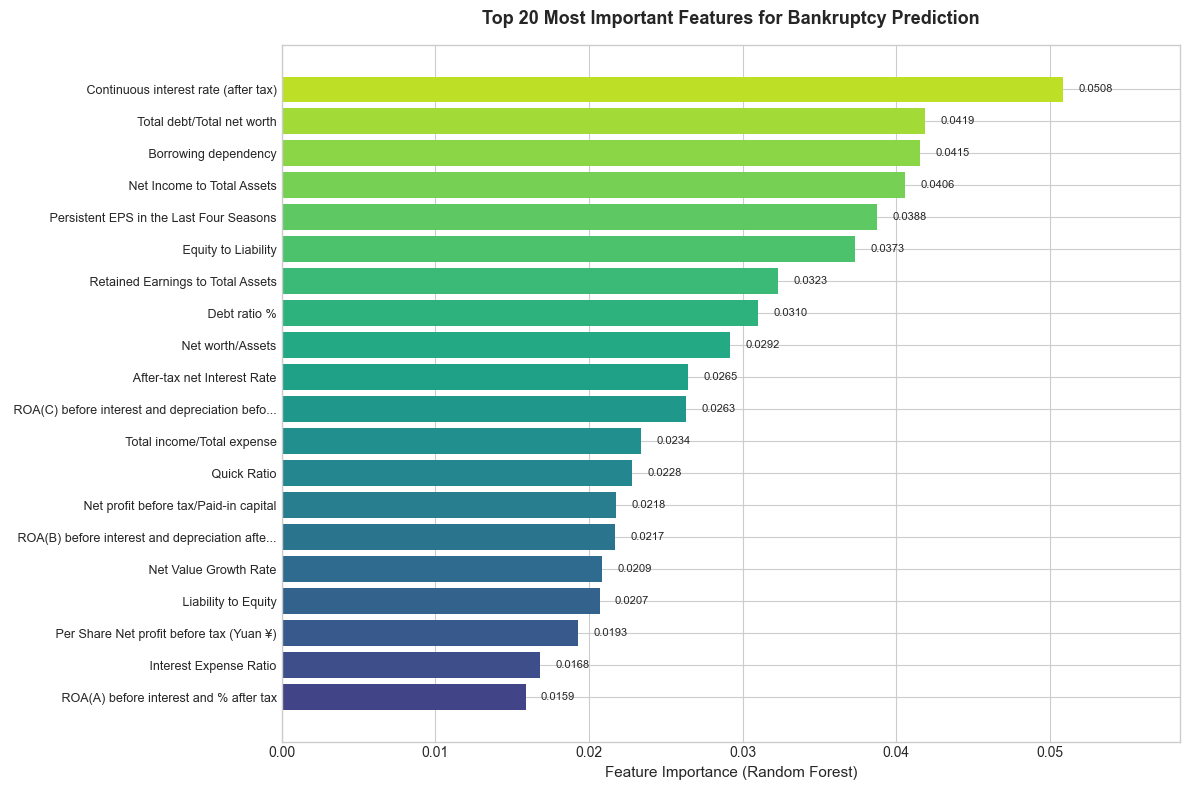


Top 20 features account for 57.9% of total importance
Top 40 features account for 77.5% of total importance


In [33]:
# Visualize Top 20 Most Important Features from Random Forest
top_20 = importances.head(20)

fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bar chart
bars = ax.barh(range(len(top_20)), top_20.values[::-1], 
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(top_20))))

# Set y-axis labels (shortened feature names)
short_names = [name[:45] + '...' if len(name) > 45 else name for name in top_20.index[::-1]]
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(short_names, fontsize=9)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_20.values[::-1])):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=8)

ax.set_xlabel('Feature Importance (Random Forest)', fontsize=11)
ax.set_title('Top 20 Most Important Features for Bankruptcy Prediction', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, top_20.values[0] * 1.15)

plt.tight_layout()
plt.show()

print(f"\nTop 20 features account for {top_20.sum()/importances.sum()*100:.1f}% of total importance")
print(f"Top 40 features account for {importances.head(40).sum()/importances.sum()*100:.1f}% of total importance")

In [9]:
X_reduced = X_var_df[top_features].copy()
print("Reduced feature matrix:", X_reduced.shape)

Reduced feature matrix: (5807, 40)


In [ ]:
joblib.dump(top_features, "top_features_for_clustering.joblib")

# Define a function-like transformer using a Pipeline
preprocess_for_clustering = Pipeline(
    steps=[
        ("select_features", 
         ("passthrough")),  # we'll apply column subsetting manually on dataframes
        ("scaler", StandardScaler())
    ]
)

In [11]:
# Fit scaler only on the selected columns
preprocess_for_clustering.named_steps["scaler"].fit(X_reduced)

# Save the fitted scaler and feature list together
preprocess_object = {
    "feature_names": top_features,
    "scaler": preprocess_for_clustering.named_steps["scaler"]
}

joblib.dump(preprocess_object, "preprocess_for_clustering.joblib")

['preprocess_for_clustering.joblib']

In [12]:
preprocess_obj = joblib.load("preprocess_for_clustering.joblib")
feature_names = preprocess_obj["feature_names"]
scaler = preprocess_obj["scaler"]

def transform_for_clustering(df_raw: pd.DataFrame) -> np.ndarray:
    """
    df_raw: full dataframe including Index and (for train) Bankrupt?
    returns: scaled, reduced feature matrix for clustering / cluster-ID
    """
    # drop target if present
    cols_to_drop = [c for c in ["Bankrupt?"] if c in df_raw.columns]
    X = df_raw.drop(columns=cols_to_drop + ["Index"])
    
    # subset to the 40 selected features
    X_sel = X[feature_names].copy()
    
    # scale
    X_scaled = scaler.transform(X_sel)
    return X_scaled

In [13]:
X_cluster = transform_for_clustering(df)
print("X_cluster shape:", X_cluster.shape)  # expect (5807, 40)

X_cluster shape: (5807, 40)


In [14]:
from sklearn.cluster import KMeans

K = 7  # or 7 if you want more subgroups
kmeans = KMeans(
    n_clusters=K,
    init="k-means++",
    n_init=20,
    random_state=42
)

cluster_labels = kmeans.fit_predict(X_cluster)
df["cluster"] = cluster_labels
df["cluster"].value_counts().sort_index()

cluster
0     728
1     701
2    2059
3       1
4    2313
5       2
6       3
Name: count, dtype: int64

In [15]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_cluster, cluster_labels)
print("Silhouette score:", sil_score)

Silhouette score: 0.138487318271109


In [16]:
joblib.dump(kmeans, "kmeans_clusters.joblib")

df.to_csv("train_with_clusters.csv", index=False)

for c in range(K):
    df_cluster_c = df[df["cluster"] == c]
    df_cluster_c.to_csv(f"cluster_{c}.csv", index=False)
    print(f"Cluster {c}: {df_cluster_c.shape[0]} rows,",
          f"{df_cluster_c['Bankrupt?'].sum()} bankrupt")

Cluster 0: 728 rows, 132 bankrupt
Cluster 1: 701 rows, 0 bankrupt
Cluster 2: 2059 rows, 6 bankrupt
Cluster 3: 1 rows, 1 bankrupt
Cluster 4: 2313 rows, 56 bankrupt
Cluster 5: 2 rows, 0 bankrupt
Cluster 6: 3 rows, 3 bankrupt
